# Recovery of the GR signal using Cutler-Vallisneri parameter bias framework

Here we align an `SEOBNRv5HMROM` template to the local pSEOBNR injection with Nelder-Mead, check the waveform residual and mismatch, and calculate the Cutler-Vallisneri parameter bias on the same frequency grid and A/E/T channel set.


In [1]:
import sys
import os

print("LAL_DATA_PATH:", os.environ["LAL_DATA_PATH"])
print(
    "exists:",
    os.path.exists(
        "/pbs/home/a/amahdi/lal_data/SEOBNRv5HMROM_v1.0.hdf5"
    )
)

LAL_DATA_PATH: /pbs/home/a/amahdi/lal_data
exists: True


In [2]:
import os
import h5py
import itertools
import copy
import numpy as np
import json
import scipy
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap, ScalarMappable
import matplotlib as mpl
from matplotlib.colors import LogNorm
import seaborn as sns
import pandas as pd

from tqdm import tqdm as tqdm

from astropy.cosmology import Planck15 as cosmo

# Using plotting settings that remain available without an external LaTeX installation.
mpl.rcParams["text.usetex"] = False
mpl.rcParams["font.family"] = "DejaVu Sans"
mpl.rcParams["mathtext.fontset"] = "dejavusans"


In [3]:
import sys
print(sys.executable)

/pbs/home/a/amahdi/.conda/envs/lisabeta/bin/python


In [4]:
import lisabeta
import lisabeta.tgr.fti as fti
import lisabeta.pyconstants as pyconstants
import lisabeta.tools.pytools as pytools
import lisabeta.tools.pyspline as pyspline
import lisabeta.tools.pyoverlap as pyoverlap
import lisabeta.lisa.pyresponse as pyresponse
import lisabeta.lisa.snrtools as snrtools
import lisabeta.lisa.pyLISAnoise as pyLISAnoise
import lisabeta.lisa.lisatools as lisatools
import lisabeta.lisa.lisa as lisa
import lisabeta.lisa.lisa_fisher as lisa_fisher
import lisabeta.utils.plotutils as plotutils
import lisabeta.inference.inference as inference
import lisabeta.utils.plotutils as plotutils

import lisabeta.waveforms.bbh.tf2 as tf2
import lal

/pbs/home/a/amahdi/lisabeta/src/lisabeta/waveforms/bbh/lalsim_wrap.py:10: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [5]:
print(lal.__path__)

['/pbs/home/a/amahdi/.conda/envs/lisabeta/lalsuite_for_lisabeta/lib/python3.10/site-packages/lal']


In [6]:
%matplotlib inline

## Defining the analysis functions


In [7]:
def plot_postraw_lnL_trace(post_raw, rangey=None, title=''):
    nwalkers = post_raw['lnL'].shape[0]
    nsteps = post_raw['lnL'].shape[1]

    # Removing sentinel likelihood values before plotting the traces.
    masks = [post_raw['lnL'][i] > -1e12 for i in range(nwalkers)]
    names = ['lnL', 'Mchirp', 'q', 'chiPN', 'chim', 'dist', 'inc', 'phi', 'lambda', 'beta', 'psi']
    nrows = len(names)

    fig, axes = plt.subplots(nrows, 1, figsize=[16, 4 * nrows])

    # Plotting the likelihood trace first.
    ax = axes[0]
    plotutils.llogplot(ax, *[[np.arange(nsteps)[masks[i]], -post_raw['lnL'][i][masks[i]]] for i in range(nwalkers)], rangey=rangey)
    ax.set_xlabel(r'$\mathrm{Steps}$')
    ax.set_ylabel(r'$-\ln \mathcal{L}$')
    ax.set_title(title)

    # Plotting the parameter traces below the likelihood.
    for ax, name in zip(axes[1:], names[1:]):
        plotutils.llogplot(ax, *[[np.arange(nsteps), post_raw[name][i]] for i in range(nwalkers)])
        ax.set_xlabel(r'$\mathrm{Steps}$')
        ax.set_ylabel(r'$\mathrm{' + name + '}$')
        ax.set_title(title)

    plt.tight_layout()
    return fig


In [8]:
def inner_product(a, b, Sn, delta_f):
    # Including the factor of 4 from the one-sided PSD inner-product convention.
    integrand = np.real(a * np.conj(b)) / Sn
    return 4 * delta_f * np.sum(integrand)

def overlap_AET_data(data1, data2, psd):
    # Using inputs defined on a common frequency grid with matching TDI channels.
    freq = data1['freq']
    diff_freq = np.diff(freq)
    tdikeys = [tdi for tdi in data1.keys() if not tdi=='freq']
    overlap = 0.
    for tdi in tdikeys:
        integrand = 4 * np.real(data1[tdi] * np.conj(data2[tdi])) / psd[tdi]
        overlap += np.sum(diff_freq * (integrand[1:] + integrand[:-1])/2)
    return overlap


In [9]:
def dh_deltah_data_smbh(params, deltah_data, steps=None, list_params=lisa_fisher.default_list_fisher_params_smbh, list_fixed_params=[], Lframe=False, fLow_from_22=True, **waveform_params):
    '''
    This updated version of Fisher computation:
      1. Adds options for additional mass parameter combinations
      2. Adds option for providing a 'prior' inverse covariance which is added to the Fisher matrix
      3. Default is as before
    '''

    waveform_params = copy.deepcopy(waveform_params)

    # Preparing the input parameters.
    Npar = len(list_params)

    LISAnoise = waveform_params.get('LISAnoise', pyLISAnoise.LISAnoiseSciRDv1)
    TDI = waveform_params.get('TDI', 'TDIAET')
    if not TDI=='TDIAET':
        raise ValueError('Data is using TDI channels among A,E,T, must have TDI=TDIAET or TDI2AET')
    TDIrescaled = waveform_params.get('TDIrescaled', True)
    LISAconst = waveform_params.get('LISAconst', pyresponse.LISAconstProposal)

    # Convertion of the input parameters between the LISA frame and SSB (Solar System Barycenter) frame.
    if not params.get('Lframe', False) and Lframe:
        params_base = lisatools.convert_SSBframe_to_Lframe(
                            params,
                            t0=waveform_params['t0'],
                            frozenLISA=waveform_params['frozenLISA'])
    elif params.get('Lframe', False) and not Lframe:
        params_base = lisatools.convert_Lframe_to_SSBframe(
                            params,
                            t0=waveform_params['t0'],
                            frozenLISA=waveform_params['frozenLISA'])
    else:
        params_base = params.copy()

    # Completing the mass and spin parametrizations.
    params_base = pytools.complete_mass_params(params_base)
    params_base = pytools.complete_spin_params(params_base)
    m1 = params_base['m1']
    m2 = params_base['m2']
    M = params_base['M']
    Ms = M * pyconstants.MTSUN_SI

    # Identifying the available TDI channels and translating their naming convention.
    tdi_channels = [k for k in deltah_data.keys() if not k=='freq']
    tdi_translate = {'TDIA':'chan1', 'TDIE':'chan2', 'TDIT':'chan3'}
    channels = [tdi_translate[k] for k in tdi_channels]
    deltah = dict([(tdi_translate[k], deltah_data[k]) for k in tdi_channels])

    # Generating the base waveform with the frequency bounds supplied in `waveform_params`.
    wftdi_base = lisa.GenerateLISATDI_SMBH(params_base, **waveform_params)

    # Reading the available modes and their frequency support from the base waveform.
    modes = wftdi_base['modes']
    fLow_lm = dict([(lm,wftdi_base[lm]['freq'][0]) for lm in modes])
    fHigh_lm = dict([(lm,wftdi_base[lm]['freq'][-1]) for lm in modes])
    # Optionally excluding the low-frequency region supported only by the (2,1) mode when its SNR contribution is negligible.
    if fLow_from_22:
        fLow = fLow_lm[(2,2)]
    else:
        fLow = np.min([fLow_lm[lm] for lm in modes])
    fHigh = np.max([fHigh_lm[lm] for lm in modes])

    # Allowing the frequency spacing to vary across the input grid.
    freqs = deltah_data['freq']
    df = np.diff(freqs)

    # Generating the base frequency series and reusing its grid for every parameter shift.
    if modes==[(2,2)]:
        gridfreq = wftdi_base[(2,2)]['freq'].copy()
    else:
        gridfreq = dict([(lm,wftdi_base[lm]['freq'].copy()) for lm in modes])
    waveform_params['gridfreq'] = gridfreq
    # Generating each shifted waveform on the fixed base grid and interpolating it onto the full data grid.
    tdifreqseries_base = lisa.GenerateLISATDIFreqseries_SMBH(params_base, freqs, **waveform_params)

    # Selecting two independent mass parameters and two independent spin parameters from the varied and fixed lists.
    list_mass_params = [p for p in list_params if p in pytools.list_mass_params]
    list_spin_params = [p for p in list_params if p in pytools.list_spin_params]
    list_fixed_mass_params = [p for p in list_fixed_params if p in pytools.list_mass_params]
    list_fixed_spin_params = [p for p in list_fixed_params if p in pytools.list_spin_params]
    list_pair_mass_params = list_mass_params + list_fixed_mass_params
    list_pair_spin_params = list_spin_params + list_fixed_spin_params
    if (not len(list_mass_params)+len(list_fixed_mass_params)==2) or (not len(list_spin_params)+len(list_fixed_spin_params)==2):
        raise ValueError('list_params + list_fixed_params must have 2 mass and spin params.')
    # Rejecting the fully degenerate `(q, eta)` mass parametrization.
    if list_pair_mass_params==['q', 'eta'] or list_pair_mass_params==['eta', 'q']:
        raise ValueError('Mass params pair (q,eta) is fully degenerate.')
    # Keeping only the selected independent mass and spin pairs.
    params_base_pair_massspin = params_base.copy()
    for p in pytools.list_mass_params:
        params_base_pair_massspin.pop(p, None)
    for p in pytools.list_spin_params:
        params_base_pair_massspin.pop(p, None)
    for p in list_pair_mass_params + list_pair_spin_params:
        params_base_pair_massspin[p] = params_base[p]

    # Evaluating the channel noise spectra on the data grid.
    noise_evaluator = pyLISAnoise.initialize_noise(LISAnoise,
                                        TDI=TDI, TDIrescaled=TDIrescaled,
                                        LISAconst=LISAconst)
    Sn1_vals, Sn2_vals, Sn3_vals = pyLISAnoise.evaluate_noise(
                          noise_evaluator, freqs,
                          TDI=TDI, TDIrescaled=TDIrescaled, LISAconst=LISAconst)
    Snvals = {}
    Snvals['chan1'] = Sn1_vals
    Snvals['chan2'] = Sn2_vals
    Snvals['chan3'] = Sn3_vals

    # Choosing the default finite-difference steps with their mass dependence.
    steps_default = lisa_fisher.get_default_steps_smbh(M)
    if steps is None:
        steps = steps_default
    else:
        steps_tmp = copy.deepcopy(steps_default)
        steps_tmp.update(steps)
        steps = steps_tmp

    # Generating the parameter-shifted signals.
    params_step = {}
    dh = {}
    for p in list_params:
        frac = lisa_fisher.dict_params_fractional[p]
        params_step = params_base_pair_massspin.copy()
        if frac:
            params_step[p] *= 1 + steps[p]
        else:
            params_step[p] += steps[p]
        params_step = pytools.complete_mass_params(params_step)
        params_step = pytools.complete_spin_params(params_step)

        tdifreqseries_step = lisa.GenerateLISATDIFreqseries_SMBH(params_step, freqs, **waveform_params)

        # Calculating the waveform derivatives with finite differences.
        dh[p] = {}
        for chan in channels:
            dh[p][chan] = np.zeros_like(freqs, dtype=complex)
            for lm in modes:
                dh[p][chan] += (tdifreqseries_step[lm][chan] - tdifreqseries_base[lm][chan]) / steps[p]

    # Inner products between each derivative and the waveform residual.
    beta = np.zeros(Npar, dtype=float)
    for i in range(Npar):
        beta[i] = 0.
        pi = list_params[i]
        for chan in channels:
            beta[i] += 4*np.sum(df * np.real(dh[pi][chan] * np.conj(deltah[chan]) / Snvals[chan])[:-1])

    # Normalization of parameters varied with fractional steps.
    scales = np.ones(len(list_params))
    for i,p in enumerate(list_params):
        if lisa_fisher.dict_params_fractional[p]:
            scales[i] = 1./params_base[p]
    scales_diag = np.diag(scales)
    scales_diag_inv = np.diag(1./scales)

    beta = np.dot(scales_diag, beta)
    
    return beta


In [10]:
def fisher_covariance_data_grid_smbh(
    params,
    reference_data,
    steps=None,
    list_params=lisa_fisher.default_list_fisher_params_smbh,
    list_fixed_params=[],
    Lframe=False,
    fLow_from_22=True,
    rcond=1e-12,
    **waveform_params
):
    """
    Fisher covariance evaluated on exactly the same frequency grid and TDI channels
    present in `reference_data`.

    This is like dh_deltah_data_smbh, but computes (dh_i|dh_j), instead of
    (dh_i|delta h).
    """
    waveform_params = copy.deepcopy(waveform_params)
    Npar = len(list_params)

    LISAnoise = waveform_params.get('LISAnoise', pyLISAnoise.LISAnoiseSciRDv1)
    TDI = waveform_params.get('TDI', 'TDIAET')
    if not TDI == 'TDIAET':
        raise ValueError('Data is using TDI channels among A,E,T, so use TDI=TDIAET here.')
    TDIrescaled = waveform_params.get('TDIrescaled', True)
    LISAconst = waveform_params.get('LISAconst', pyresponse.LISAconstProposal)

    # Converting the input parameters consistently between the L frame and SSB frame.
    if not params.get('Lframe', False) and Lframe:
        params_base = lisatools.convert_SSBframe_to_Lframe(
            params,
            t0=waveform_params['t0'],
            frozenLISA=waveform_params['frozenLISA']
        )
    elif params.get('Lframe', False) and not Lframe:
        params_base = lisatools.convert_Lframe_to_SSBframe(
            params,
            t0=waveform_params['t0'],
            frozenLISA=waveform_params['frozenLISA']
        )
    else:
        params_base = params.copy()

    params_base = pytools.complete_mass_params(params_base)
    params_base = pytools.complete_spin_params(params_base)

    m1 = params_base['m1']
    m2 = params_base['m2']
    M = params_base['M']

    # Use only the TDI channels present in the data or residual.
    tdi_channels = [k for k in ['TDIA', 'TDIE', 'TDIT'] if k in reference_data]
    if not tdi_channels:
        raise ValueError("reference_data must contain at least one of TDIA, TDIE, TDIT.")

    tdi_translate = {'TDIA': 'chan1', 'TDIE': 'chan2', 'TDIT': 'chan3'}
    channels = [tdi_translate[k] for k in tdi_channels]

    freqs = np.asarray(reference_data['freq'])
    df = np.diff(freqs)

    # Generate the base waveform once to determine the mode support and fixed frequency grid.
    wftdi_base = lisa.GenerateLISATDI_SMBH(params_base, **waveform_params)
    modes = wftdi_base['modes']

    if modes == [(2, 2)]:
        gridfreq = wftdi_base[(2, 2)]['freq'].copy()
    else:
        gridfreq = {lm: wftdi_base[lm]['freq'].copy() for lm in modes}

    waveform_params['gridfreq'] = gridfreq
    tdifreqseries_base = lisa.GenerateLISATDIFreqseries_SMBH(params_base, freqs, **waveform_params)

    # Use the same independent mass and spin pairs as in `dh_deltah_data_smbh`.
    list_mass_params = [p for p in list_params if p in pytools.list_mass_params]
    list_spin_params = [p for p in list_params if p in pytools.list_spin_params]
    list_fixed_mass_params = [p for p in list_fixed_params if p in pytools.list_mass_params]
    list_fixed_spin_params = [p for p in list_fixed_params if p in pytools.list_spin_params]
    list_pair_mass_params = list_mass_params + list_fixed_mass_params
    list_pair_spin_params = list_spin_params + list_fixed_spin_params

    if (not len(list_pair_mass_params) == 2) or (not len(list_pair_spin_params) == 2):
        raise ValueError('list_params + list_fixed_params must have 2 mass and 2 spin params.')
    if list_pair_mass_params == ['q', 'eta'] or list_pair_mass_params == ['eta', 'q']:
        raise ValueError('Mass params pair (q, eta) is fully degenerate.')

    params_base_pair_massspin = params_base.copy()
    for p in pytools.list_mass_params:
        params_base_pair_massspin.pop(p, None)
    for p in pytools.list_spin_params:
        params_base_pair_massspin.pop(p, None)
    for p in list_pair_mass_params + list_pair_spin_params:
        params_base_pair_massspin[p] = params_base[p]

    # Evaluate the noise spectra on the same frequency grid.
    noise_evaluator = pyLISAnoise.initialize_noise(
        LISAnoise,
        TDI=TDI,
        TDIrescaled=TDIrescaled,
        LISAconst=LISAconst
    )
    Sn1_vals, Sn2_vals, Sn3_vals = pyLISAnoise.evaluate_noise(
        noise_evaluator,
        freqs,
        TDI=TDI,
        TDIrescaled=TDIrescaled,
        LISAconst=LISAconst
    )
    Snvals = {'chan1': Sn1_vals, 'chan2': Sn2_vals, 'chan3': Sn3_vals}

    steps_default = lisa_fisher.get_default_steps_smbh(M)
    if steps is None:
        steps = steps_default
    else:
        steps_tmp = copy.deepcopy(steps_default)
        steps_tmp.update(steps)
        steps = steps_tmp

    # Calculate the derivatives on the same frequencies and TDI channels.
    dh = {}
    for p in list_params:
        frac = lisa_fisher.dict_params_fractional[p]
        params_step = params_base_pair_massspin.copy()
        if frac:
            params_step[p] *= 1 + steps[p]
        else:
            params_step[p] += steps[p]

        params_step = pytools.complete_mass_params(params_step)
        params_step = pytools.complete_spin_params(params_step)

        tdifreqseries_step = lisa.GenerateLISATDIFreqseries_SMBH(params_step, freqs, **waveform_params)

        dh[p] = {}
        for chan in channels:
            dh[p][chan] = np.zeros_like(freqs, dtype=complex)
            for lm in modes:
                dh[p][chan] += (
                    tdifreqseries_step[lm][chan]
                    - tdifreqseries_base[lm][chan]
                ) / steps[p]

    fish = np.zeros((Npar, Npar), dtype=float)

    for i, pi in enumerate(list_params):
        for j, pj in enumerate(list_params[i:], start=i):
            val = 0.0
            for chan in channels:
                integrand = np.real(dh[pi][chan] * np.conj(dh[pj][chan]) / Snvals[chan])
                val += 4.0 * np.sum(df * integrand[:-1])
            fish[i, j] = val
            fish[j, i] = val

    # Restoring the fractional-step normalization used in `dh_deltah_data_smbh`.
    scales = np.ones(len(list_params))
    for i, p in enumerate(list_params):
        if lisa_fisher.dict_params_fractional[p]:
            scales[i] = 1.0 / params_base[p]

    scales_diag = np.diag(scales)
    fish = scales_diag @ fish @ scales_diag

    cond = np.linalg.cond(fish)
    try:
        cov = np.linalg.inv(fish)
        inversion = "inv"
    except np.linalg.LinAlgError:
        cov = np.linalg.pinv(fish, rcond=rcond)
        inversion = f"pinv(rcond={rcond:g})"

    return {
        'fish': fish,
        'cov': cov,
        'freq': freqs,
        'channels': tdi_channels,
        'list_params': list_params,
        'condition_number': cond,
        'inversion': inversion,
    }


In [11]:
def format_mass_title(mass_str, use_latex=True):
    """
    Formatting labels such as `me5` and `2me5` as plain-text or LaTeX mass values.
    """
    clean_str = mass_str.lower()
    parts = clean_str.split('me')
    
    if len(parts) != 2:
        return mass_str  # Returning the original label when the expected pattern is absent.
        
    mantissa, exponent = parts
    
    # Handling labels without an explicit mantissa, such as `me5`.
    if mantissa == '':
        if use_latex:
            return fr"$M = 10^{{{exponent}}} M_{{\odot}}$"
        else:
            return f"10^{exponent}"
            
    # Handle labels with an explicit mantissa, such as `2me5`.
    else:
        if use_latex:
            return fr"${mantissa} \\times 10^{{{exponent}}}  M_{{\odot}}$"
        else:
            return f"{mantissa}*10^{exponent}"


In [12]:
import os
import h5py

# Using the same absolute directory as the injection notebook.
subsdir = "/pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Null_test"
datadir = "/pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Null_test"

print("datadir:", datadir)
print("datadir absolute:", os.path.abspath(datadir))


datadir: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Null_test
datadir absolute: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Null_test


## Loading the injection and setting the recovery parameters


In [13]:
mass = 'me6'
m_str = 'M1e6'
inj_id = 0

wf_rec = 'SEOB'

if wf_rec == 'SEOB': 
    wf_name = 'SEOBNRv5HMROM'
elif wf_rec == 'XHM': 
    wf_name = 'PhenomXHM'
else:
    raise ValueError(f"Unknown wf_rec = {wf_rec}")

mass_name = format_mass_title(mass)

# Keep the FTI parameters at zero and inactive for the GR consistency calculation.
FTI_ZERO_PARAMS = [
    "fti_dchiMinus2v", "fti_dchi0v", "fti_dchi1v", "fti_dchi2v",
    "fti_dchi3v", "fti_dchi4v", "fti_dchi5lv", "fti_dchi6v",
    "fti_dchi6lv", "fti_dchi7v", "fti_dkappa_S", "fti_dxi0v",
]
fti_param = "fti_dchiMinus2v"

# Load the injection parameters from the directory used by the injection notebook.
params_file = os.path.join(datadir, f"params_injection_set_{m_str}.h5")
data_file = os.path.join(datadir, m_str, f"data_pseob_{m_str}_id_{inj_id}.h5")

print("Reading params:", params_file)
print("Reading data:  ", data_file)

with h5py.File(params_file, 'r') as hf:
    params = {
        'M': float(hf['M'][inj_id]),
        'q': float(hf['q'][inj_id]),
        'chi1': float(hf['chi1'][inj_id]),
        'chi2': float(hf['chi2'][inj_id]),
        'dist': float(hf['dist'][inj_id]),
        'inc': float(hf['inc'][inj_id]),
        'phi': float(hf['phi'][inj_id]),
        'lambda': float(hf['lambda'][inj_id]),
        'beta': float(hf['beta'][inj_id]),
        'psi': float(hf['psi'][inj_id]),
        'Deltat': float(hf['Deltat'][inj_id]),
        'Lframe': bool(hf['Lframe'][:][0]),
    }

    for p in FTI_ZERO_PARAMS:
        params[p] = float(hf[p][inj_id]) if p in hf else 0.0

# Loading the TDI injection data.
tdidata_injected = inference.load_data_TDIAET(data_file)

# Adding any TDI datasets that are present in the HDF5 file but missing from the lisabeta loader output.
with h5py.File(data_file, "r") as hf:
    for key in ["freq", "TDIA", "TDIE", "TDIT"]:
        if key in hf and key not in tdidata_injected:
            tdidata_injected[key] = hf[key][:]

GR_param = [
    'Mchirp', 'q', 'chiPN', 'chim', 'Deltat',
    'dist', 'inc', 'phi', 'lambda', 'beta', 'psi'
]

FTI_param = GR_param + [fti_param]

print("Loaded data channels:", [k for k in tdidata_injected.keys() if k != "freq"])
print("Data frequency range:", tdidata_injected["freq"][0], tdidata_injected["freq"][-1], "N=", len(tdidata_injected["freq"]))


Reading params: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Null_test/params_injection_set_M1e6.h5
Reading data:   /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Null_test/M1e6/data_pseob_M1e6_id_0.h5
Loaded data channels: ['TDIA', 'TDIE', 'TDIT']
Data frequency range: 8.229645274606691e-05 0.2 N= 32723


In [14]:
# Inspect the parameters loaded from `params_injection_set_<M>.h5`; changing them here only for a deliberate test.
params


{'M': 1000000.0,
 'q': 4.0,
 'chi1': 0.5,
 'chi2': 0.5,
 'dist': 6791.810623950696,
 'inc': 1.0471975511965976,
 'phi': 0.7,
 'lambda': 1.0,
 'beta': 0.5235987755982988,
 'psi': 1.2,
 'Deltat': 0.0,
 'Lframe': True,
 'fti_dchiMinus2v': 0.0,
 'fti_dchi0v': 0.0,
 'fti_dchi1v': 0.0,
 'fti_dchi2v': 0.0,
 'fti_dchi3v': 0.0,
 'fti_dchi4v': 0.0,
 'fti_dchi5lv': 0.0,
 'fti_dchi6v': 0.0,
 'fti_dchi6lv': 0.0,
 'fti_dchi7v': 0.0,
 'fti_dkappa_S': 0.0,
 'fti_dxi0v': 0.0}

In [15]:
# Setting the recovery waveform on the frequency interval supplied by the injected data.
RECOVERY_MODES = [(2, 2), (2, 1), (3, 3), (4, 4), (4, 3), (5, 5)]

waveform_params = {
    "minf": float(tdidata_injected["freq"][0]),
    "maxf": float(tdidata_injected["freq"][-1]),
    "t0": 0.0,
    "timetomerger_max": 2.0,
    "fend": None,
    "tmin": None,
    "tmax": None,
    "phiref": 0.0,
    "fref_for_phiref": 0.0,
    "tref": 0.0,
    "fref_for_tref": 0.0,
    "force_phiref_fref": True,
    "toffset": 0.0,
    "modes": RECOVERY_MODES,
    "TDI": "TDIAET",
    "acc": 0.0001,
    "order_fresnel_stencil": 0,
    "approximant": wf_name,
    "LISAconst": "Proposal",
    "responseapprox": "full",
    "frozenLISA": False,
    "TDIrescaled": True,
    "LISAnoise": {
        "InstrumentalNoise": "SciRDv1",
        "WDbackground": True,
        "WDduration": 4.0,
        "lowf_add_pm_noise_f0": 0.0,
        "lowf_add_pm_noise_alpha": 2.0
    }
}

# Keeping the FTI bookkeeping explicit while leaving `tgr_params` inactive for the GR consistency check.
for p in FTI_ZERO_PARAMS:
    params[p] = 0.0

print("Recovery frequency range:", waveform_params["minf"], waveform_params["maxf"])
print("Recovery modes:", waveform_params["modes"])
print("FTI parameters inactive and set to zero in params.")


Recovery frequency range: 8.229645274606691e-05 0.2
Recovery modes: [(2, 2), (2, 1), (3, 3), (4, 4), (4, 3), (5, 5)]
FTI parameters inactive and set to zero in params.


In [16]:
params_complete_mass = pytools.complete_mass_params(params)
print(params_complete_mass['Mchirp'])

333021.2829607493


In [17]:
import os, sys
import lal
import lalsimulation as lalsim

print("approximant:", waveform_params["approximant"])
print("LAL_DATA_PATH:", os.environ.get("LAL_DATA_PATH"))
print("python:", sys.executable)
print("lal:", lal.__version__)
print("lalsimulation:", lalsim.__file__)

approximant: SEOBNRv5HMROM
LAL_DATA_PATH: /pbs/home/a/amahdi/lal_data
python: /pbs/home/a/amahdi/.conda/envs/lisabeta/bin/python
lal: 7.7.0.1
lalsimulation: /pbs/home/a/amahdi/.conda/envs/lisabeta/lalsuite_for_lisabeta/lib/python3.10/site-packages/lalsimulation/__init__.py


## Aligning the recovery waveform with Nelder-Mead


In [18]:
likelihood = lisa.LikelihoodLISASMBH_Data(params, data=tdidata_injected, **waveform_params)

Deltat_max = 200.
    
def f_opt(x):
    params_NM = params.copy()
    
    # Converting the scaled time shift back to seconds before evaluating the likelihood.
    params_NM['Deltat'] = Deltat_max * x[0]
    params_NM['phi'] = x[1]
    params_NM['psi'] = x[2]
    
    # Rejecting time shifts outside the chosen optimization interval.
    if np.abs(x[0]) > 1.0: 
        return np.inf
    else:
        # Returning the negative log likelihood because SciPy minimizes the objective.
        return -likelihood.lnL(params_NM, ngrid=128, **waveform_params)

Ntries = 10

# Drawing independent physical starting points for the optimizer.
Deltat_tries = np.random.uniform(-Deltat_max, Deltat_max, size=Ntries)
phi_tries = np.random.uniform(-np.pi, np.pi, size=Ntries)
psi_tries = np.random.uniform(0., np.pi, size=Ntries)

# Choosing one common simplex scale after normalizing the time shift.
scale = 0.5 
res_neldermead = {}

for j in tqdm(range(Ntries)):
    # Scaling the initial time shift to the interval used by the optimizer.
    x0 = np.array([Deltat_tries[j] / Deltat_max, phi_tries[j], psi_tries[j]])
    
    initial_simplex = np.array([
        x0, 
        x0 + scale * np.array([1,0,0]), 
        x0 + scale * np.array([0,1,0]), 
        x0 + scale * np.array([0,0,1])
    ])

    res_neldermead[j] = scipy.optimize.minimize(
        f_opt,
        x0,
        args=(),
        method='Nelder-Mead',
        options={'initial_simplex': initial_simplex, 'return_all': True}
    )


100%|██████████| 10/10 [01:28<00:00,  8.80s/it]


In [19]:
# Selecting the trial with the smallest negative log likelihood.
best_j = min(res_neldermead, key=lambda k: res_neldermead[k].fun)

best_result = res_neldermead[best_j]

print(f"Best trial: {best_j}")
print(f"Minimum Value (Negative lnL): {best_result.fun}")
print(f"Best Parameters (Scaled): {best_result.x}")


Best trial: 6
Minimum Value (Negative lnL): 92.29564674018411
Best Parameters (Scaled): [-0.0262555   2.04853666  4.34164336]


In [20]:
def process_nelder_mead_result(best_x, Deltat_max=200.):
    # Converting the optimized time shift back to seconds.
    deltat_true = best_x[0] * Deltat_max
    
    # Wrapping the optimized orbital phase to the interval [-π, π].
    phi_true = (best_x[1] + np.pi) % (2 * np.pi) - np.pi
    
    # Wrapping the polarization angle to the interval [0, π].
    psi_true = best_x[2] % np.pi
    
    return {
        'Deltat': deltat_true,
        'phi': phi_true,
        'psi': psi_true
    }


In [21]:
best_x_raw = np.array(best_result.x)
ML_values = process_nelder_mead_result(best_x_raw)

print(ML_values)

{'Deltat': np.float64(-5.251100450264658), 'phi': np.float64(2.0485366599712336), 'psi': np.float64(1.200050709632535)}


## Calculating the Cutler-Vallisneri bias


### Using one data space throughout the CV calculation

Computing the residual, beta vector, Fisher matrix, and covariance on the injected frequency grid and using the same available TDI channels throughout. The injected file determines whether A/E or A/E/T is used. The FTI parameters remain present only as zero-valued bookkeeping entries for this GR consistency calculation.


In [22]:
GR_param  = ['Mchirp', 'q', 'chiPN', 'chim', 'Deltat', 'dist', 'inc', 'phi', 'lambda', 'beta', 'psi']
alignment_param = ['Deltat','phi','psi']

In [23]:
injection_align = params.copy()
for p in alignment_param: 
    injection_align[p] = ML_values[p]

In [24]:
injection_align

{'M': 1000000.0,
 'q': 4.0,
 'chi1': 0.5,
 'chi2': 0.5,
 'dist': 6791.810623950696,
 'inc': 1.0471975511965976,
 'phi': np.float64(2.0485366599712336),
 'lambda': 1.0,
 'beta': 0.5235987755982988,
 'psi': np.float64(1.200050709632535),
 'Deltat': np.float64(-5.251100450264658),
 'Lframe': True,
 'fti_dchiMinus2v': 0.0,
 'fti_dchi0v': 0.0,
 'fti_dchi1v': 0.0,
 'fti_dchi2v': 0.0,
 'fti_dchi3v': 0.0,
 'fti_dchi4v': 0.0,
 'fti_dchi5lv': 0.0,
 'fti_dchi6v': 0.0,
 'fti_dchi6lv': 0.0,
 'fti_dchi7v': 0.0,
 'fti_dkappa_S': 0.0,
 'fti_dxi0v': 0.0}

In [25]:
freq_grid = tdidata_injected['freq']

tdifreqseries = lisa.GenerateLISATDIFreqseries_SMBH(injection_align, freq_grid, **waveform_params)

tdi_align = {
    'freq': freq_grid.copy(),
    'TDIA': np.zeros(len(freq_grid), dtype=complex),
    'TDIE': np.zeros(len(freq_grid), dtype=complex),
    'TDIT': np.zeros(len(freq_grid), dtype=complex),
}

# Summing the modes returned by the recovery waveform generator.
for lm in tdifreqseries['modes']:
    tdi_align['TDIA'] += tdifreqseries[lm]['chan1']
    tdi_align['TDIE'] += tdifreqseries[lm]['chan2']
    tdi_align['TDIT'] += tdifreqseries[lm]['chan3']

# Using only the TDI channels shared by the injected data and the recovery waveform.
TDI_CHANNELS = [chan for chan in ['TDIA', 'TDIE', 'TDIT'] if chan in tdidata_injected and chan in tdi_align]
USE_TDIT = 'TDIT' in TDI_CHANNELS

lisa_psd = pyLISAnoise.evaluate_AET_psd(freq_grid, TDIT=USE_TDIT, **waveform_params)

print("Channels used for residual/beta/Fisher/mismatch:", TDI_CHANNELS)
print("Frequency grid used:", freq_grid[0], freq_grid[-1], len(freq_grid))


Channels used for residual/beta/Fisher/mismatch: ['TDIA', 'TDIE', 'TDIT']
Frequency grid used: 8.229645274606691e-05 0.2 32723


In [26]:
residual_align = {'freq': tdidata_injected['freq'].copy()}

for chan in TDI_CHANNELS:
    residual_align[chan] = tdi_align[chan] - tdidata_injected[chan]

print("Residual channels:", [k for k in residual_align.keys() if k != "freq"])


Residual channels: ['TDIA', 'TDIE', 'TDIT']


In [27]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams["text.usetex"] = False
mpl.rcParams["font.family"] = "serif"

# Clearing the previous figure state before plotting the diagnostics.
plt.close("all")


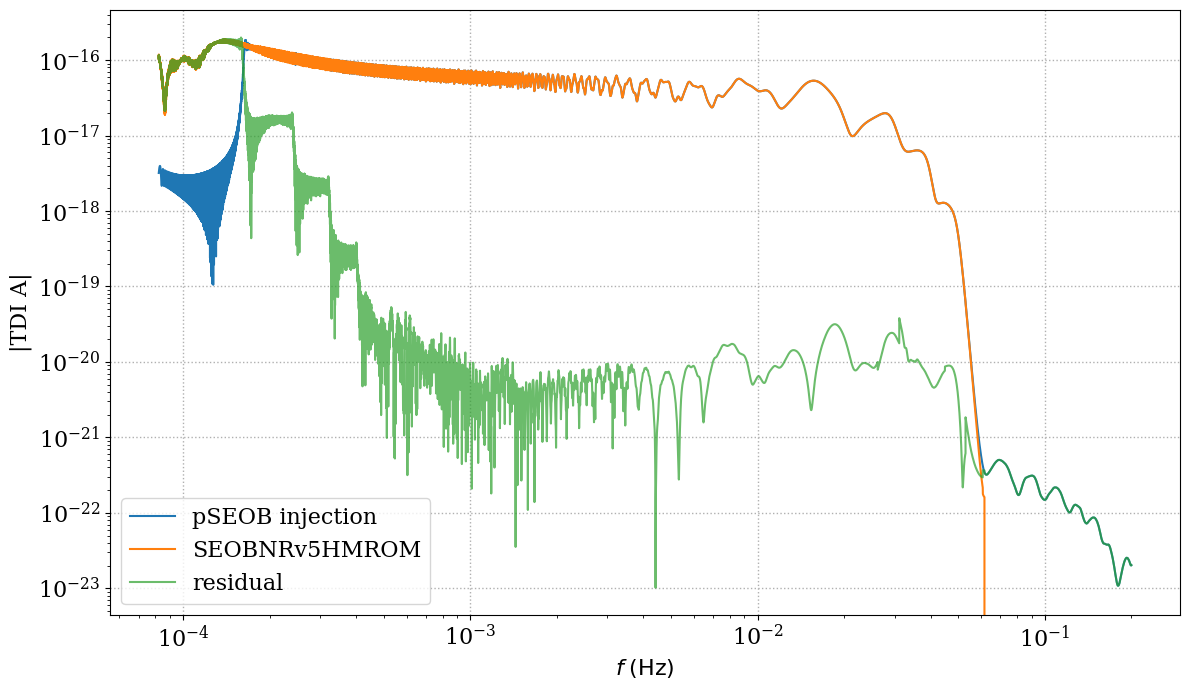

In [28]:
plt.figure(figsize=(12, 7))

plt.loglog(tdidata_injected['freq'], np.abs(tdidata_injected['TDIA']), label='pSEOB injection')
plt.loglog(tdi_align['freq'], np.abs(tdi_align['TDIA']), label = f'{wf_name}')
plt.loglog(residual_align['freq'], np.abs(residual_align['TDIA']), label='residual', alpha = 0.7)
# plt.loglog(f,np.sqrt(Sn_wd*f), label = '$h_n$')

plt.xlabel(r'$f \; (\mathrm{Hz})$')
plt.ylabel(r'|TDI A|')
# plt.xlim(1e-5, 0.5)
# plt.xlim(tdi_SEOB_align['freq'][0], 0.5)
# plt.ylim(1e-25,5e-16)
plt.legend(loc='lower left')
plt.tight_layout()
# fig.savefig(f'/work/LISA/piarulm/FTI/PE_analysis/Systematics_work/run_data/residual_me6.pdf')


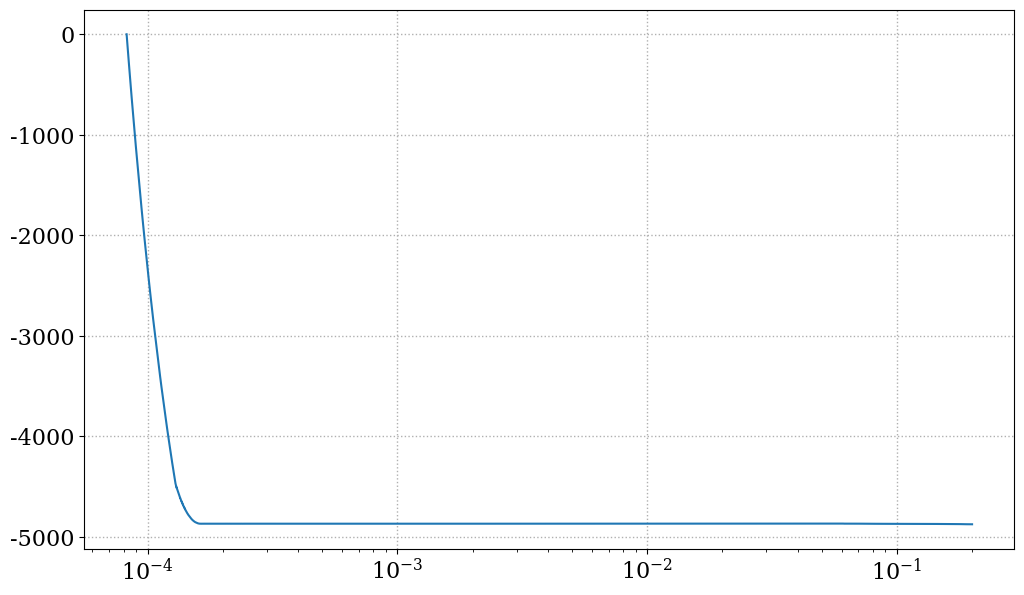

In [29]:
plt.figure(figsize=(12, 7))

plt.plot(tdidata_injected['freq'], np.unwrap(np.angle(tdi_align['TDIA'])) - np.unwrap(np.angle(tdidata_injected['TDIA'])))
plt.xscale('log')

### Checking the waveform mismatch


In [30]:
overlap_12 = overlap_AET_data(tdidata_injected, tdi_align, lisa_psd)
overlap_11 = overlap_AET_data(tdidata_injected, tdidata_injected, lisa_psd)
overlap_22 = overlap_AET_data(tdi_align, tdi_align, lisa_psd)

norm_factor = np.sqrt(overlap_11) * np.sqrt(overlap_22)
match = np.abs(overlap_12) / norm_factor
mismatch = 1 - match

# Keeping the parameter-space dimension available for the indistinguishability criterion.
D = 11

print(f"Match (max over time, phase, pol): {match:.6f}")
print(f"Mismatch: {mismatch:.6e}")


Match (max over time, phase, pol): 0.999976
Mismatch: 2.391151e-05


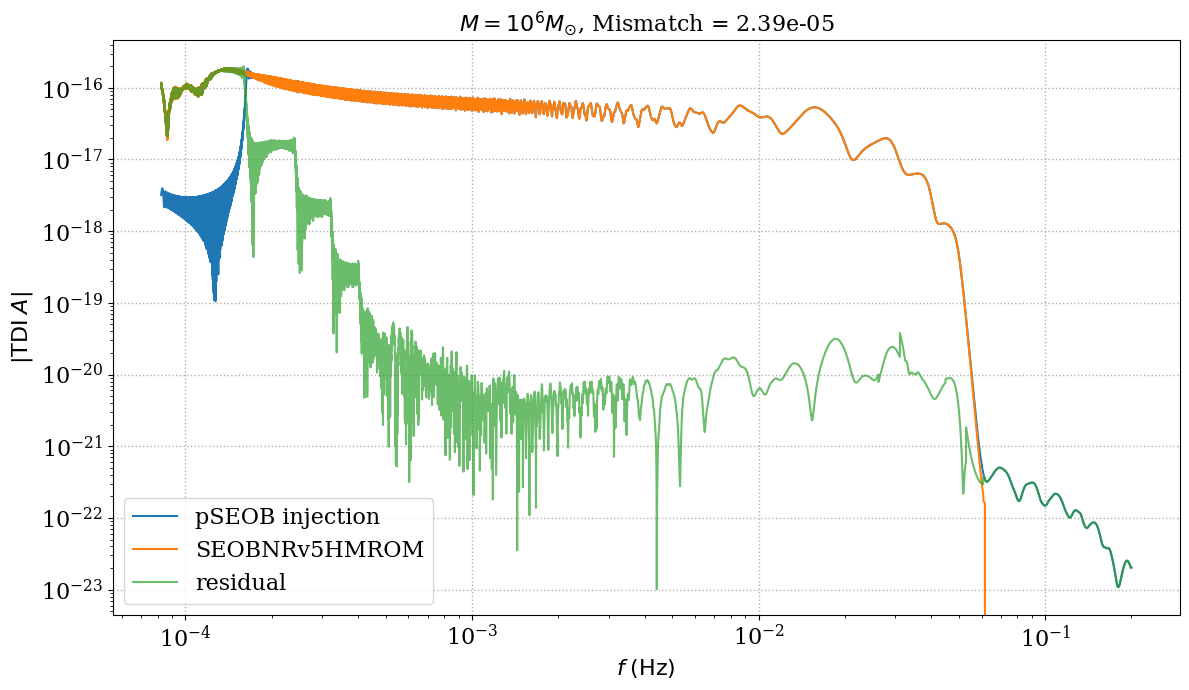

Saved figure to: /pbs/home/a/amahdi/pySEOBNR_deviation_2/Data/Null_test/M1e6/$M = 10^{6} M_{\odot}$_SEOBNRv5HMROM_TDIA_residual_mismatch_2.39e-05.png


In [31]:
import os
import matplotlib.pyplot as plt

out_dir = os.path.join(datadir, m_str)
os.makedirs(out_dir, exist_ok=True)

out_file = os.path.join(
    out_dir,
    f"{mass_name}_{wf_name}_TDIA_residual_mismatch_{mismatch:.2e}.png"
)

plt.figure(figsize=(12, 7))

plt.loglog(tdidata_injected['freq'], np.abs(tdidata_injected['TDIA']), label='pSEOB injection')
plt.loglog(tdi_align['freq'], np.abs(tdi_align['TDIA']), label=f'{wf_name}')
plt.loglog(residual_align['freq'], np.abs(residual_align['TDIA']), label='residual', alpha=0.7)

plt.xlabel(r'$f \; (\mathrm{Hz})$')
plt.ylabel(r'$|{\rm TDI}\; A|$')
plt.legend(loc='lower left')
plt.title(rf"{mass_name}, Mismatch = {mismatch:.2e}")
plt.tight_layout()

plt.savefig(out_file, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {out_file}")

In [32]:
# Using the aligned template parameters for the smooth-grid diagnostic.
template_params = injection_align.copy()
waveform_params_plot = waveform_params.copy()


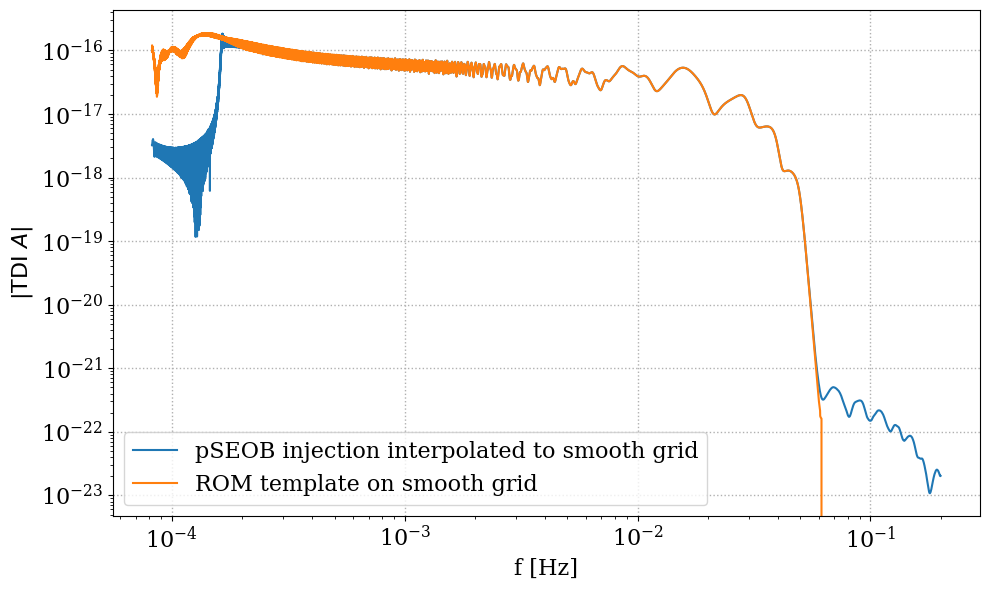

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Building a smooth logarithmic frequency grid for plotting.
freq_grid_smooth = np.geomspace(
    tdidata_injected["freq"][0],
    tdidata_injected["freq"][-1],
    50000
)

# Generating the aligned template on the smooth grid.
tdifreqseries_smooth = lisa.GenerateLISATDIFreqseries_SMBH(
    template_params,
    freq_grid_smooth,
    **waveform_params_plot
)

tdi_smooth = {
    "freq": freq_grid_smooth,
    "TDIA": np.zeros(len(freq_grid_smooth), dtype=complex),
    "TDIE": np.zeros(len(freq_grid_smooth), dtype=complex),
    "TDIT": np.zeros(len(freq_grid_smooth), dtype=complex),
}

for lm in tdifreqseries_smooth["modes"]:
    tdi_smooth["TDIA"] += tdifreqseries_smooth[lm]["chan1"]
    tdi_smooth["TDIE"] += tdifreqseries_smooth[lm]["chan2"]
    tdi_smooth["TDIT"] += tdifreqseries_smooth[lm]["chan3"]


# Interpolate the injection onto the same smooth grid.
tdi_inj_smooth = {
    "freq": freq_grid_smooth,
}

for chan in TDI_CHANNELS:
    inj_real = np.interp(
        freq_grid_smooth,
        tdidata_injected["freq"],
        np.real(tdidata_injected[chan])
    )

    inj_imag = np.interp(
        freq_grid_smooth,
        tdidata_injected["freq"],
        np.imag(tdidata_injected[chan])
    )

    tdi_inj_smooth[chan] = inj_real + 1j * inj_imag


# Calculating the residual on the smooth grid.
residual_smooth = {
    "freq": freq_grid_smooth,
}

for chan in TDI_CHANNELS:
    residual_smooth[chan] = tdi_smooth[chan] - tdi_inj_smooth[chan]


# Plotting the injected and recovered TDI A amplitudes.
plt.figure(figsize=(10, 6))

plt.loglog(
    tdi_inj_smooth["freq"],
    np.abs(tdi_inj_smooth["TDIA"]),
    label="pSEOB injection interpolated to smooth grid"
)

plt.loglog(
    tdi_smooth["freq"],
    np.abs(tdi_smooth["TDIA"]),
    label="ROM template on smooth grid"
)

'''plt.loglog(
    residual_smooth["freq"],
    np.abs(residual_smooth["TDIA"]),
    label="residual on smooth grid",
    alpha=0.7
)'''

plt.xlabel("f [Hz]")
plt.ylabel(r"$|\mathrm{TDI}\ A|$")
plt.legend()
plt.tight_layout()
plt.show()


In [34]:
injection_align = pytools.complete_mass_params(injection_align)

# Check that the beta, Fisher, covariance, and CV normalization use the same grid and channels.
print("CV grid:", residual_align["freq"][0], residual_align["freq"][-1], len(residual_align["freq"]))
print("CV channels:", [k for k in residual_align.keys() if k != "freq"])
print("waveform_params min/max:", waveform_params["minf"], waveform_params["maxf"])

beta = dh_deltah_data_smbh(
    injection_align,
    residual_align,
    list_params=GR_param,
    Lframe=True,
    **waveform_params
)


CV grid: 8.229645274606691e-05 0.2 32723
CV channels: ['TDIA', 'TDIE', 'TDIT']
waveform_params min/max: 8.229645274606691e-05 0.2


In [35]:
fishercov = fisher_covariance_data_grid_smbh(
    injection_align,
    residual_align,
    list_params=GR_param,
    Lframe=True,
    **waveform_params
)

print("Fisher channels:", fishercov["channels"])
print("Fisher grid:", fishercov["freq"][0], fishercov["freq"][-1], len(fishercov["freq"]))
print("Fisher condition number:", fishercov["condition_number"])
print("Fisher inversion:", fishercov["inversion"])
print("Sigmas:", {p: np.sqrt(fishercov["cov"][i, i]) for i, p in enumerate(GR_param)})


Fisher channels: ['TDIA', 'TDIE', 'TDIT']
Fisher grid: 8.229645274606691e-05 0.2 32723
Fisher condition number: 2982403477161.3135
Fisher inversion: inv
Sigmas: {'Mchirp': np.float64(3.9563611971917885), 'q': np.float64(0.005349279782187938), 'chiPN': np.float64(0.00030252028104751504), 'chim': np.float64(0.002384080737806168), 'Deltat': np.float64(0.08750986974330643), 'dist': np.float64(29.185142774938384), 'inc': np.float64(0.0029876061661113533), 'phi': np.float64(0.016788308519578524), 'lambda': np.float64(0.003539197869136713), 'beta': np.float64(0.0016587373977957917), 'psi': np.float64(0.004075082324030926)}


In [36]:
deltatheta = np.dot(fishercov['cov'], -beta)

cv_table = pd.DataFrame({
    "param": GR_param,
    "beta": beta,
    "delta_theta": deltatheta,
    "sigma": [np.sqrt(fishercov["cov"][i, i]) for i in range(len(GR_param))],
    "delta_theta_over_sigma": [
        deltatheta[i] / np.sqrt(fishercov["cov"][i, i])
        for i in range(len(GR_param))
    ],
})
cv_table


,param,beta,delta_theta,sigma,delta_theta_over_sigma
0,Mchirp,0.011647,0.441936,3.956361,0.111703
1,q,59.984064,0.001476,0.005349,0.275932
2,chiPN,-3151.987028,0.000072,0.000303,0.238557
3,chim,-266.510308,0.000242,0.002384,0.101665
4,Deltat,0.312182,-0.016171,0.087510,-0.184792
5,dist,-0.036181,10.486717,29.185143,0.359317
6,inc,-326.614311,-0.000467,0.002988,-0.156369
7,phi,26.567515,0.005207,0.016788,0.310184
8,lambda,-5.004815,0.000564,0.003539,0.159331
9,beta,-15.424165,0.000782,0.001659,0.471521


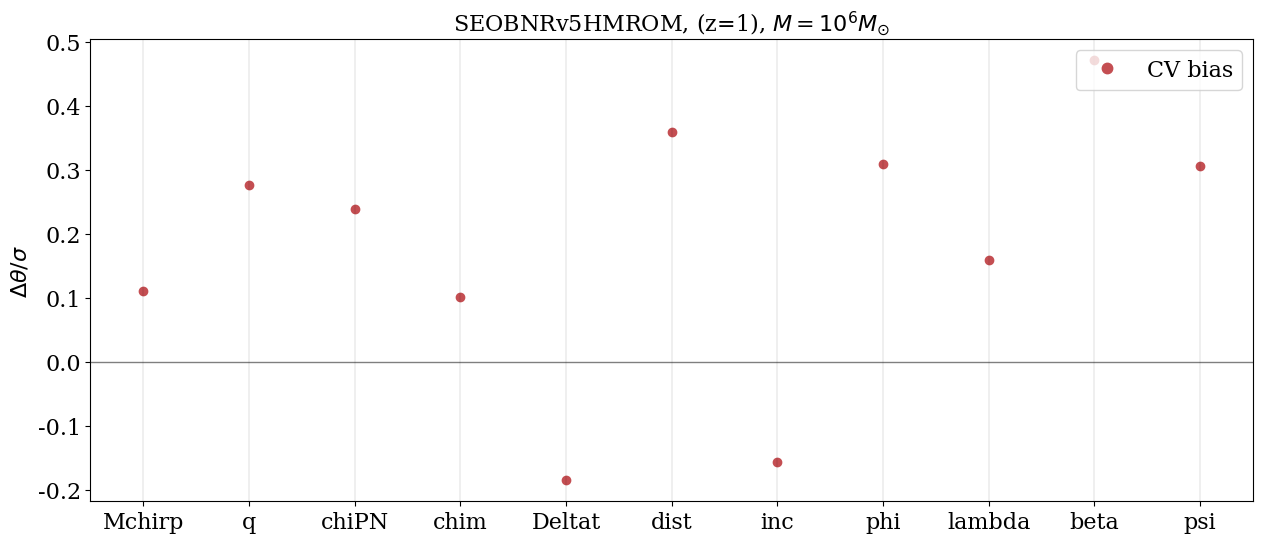

In [37]:
scales = dict([(p,np.sqrt(fishercov['cov'][i,i])) for i,p in enumerate(GR_param)])
# Setting up one panel for the normalized CV biases.
fig, ax1 = plt.subplots(1, 1, figsize=[15, 6])

# Placing the recovered parameters along the horizontal axis.
pos1 = np.arange(1, len(GR_param) + 1)
scat1 = [deltatheta[i] / scales[p] for i, p in enumerate(GR_param)]

# Plotting the CV bias of each parameter in units of its Fisher uncertainty.
ax1.scatter(pos1, scat1, color=plotutils.plotpalette[1])

# Formatting the axes and reference line.
ax1.set_xticks(pos1, labels=GR_param)
ax1.set_ylabel(r'$\Delta \theta / \sigma $')
ax1.set_title(f'{wf_name}, (z=1), {mass_name}')
ax1.axhline(0., c='k', lw=1., alpha=0.5)
ax1.grid(False)

# Adding light vertical separators between parameters.
for x in pos1:
    ax1.axvline(x, c='k', lw=0.3, alpha=0.3)

# Adding the CV-bias legend.
handles = [
    mpl.lines.Line2D([], [], marker='.', markersize=15, color=plotutils.plotpalette[1], linestyle='None')
]
ax1.legend(handles, [r'CV bias'], loc='upper right')

# Saving the CV-bias figure in the configured run-data directory.
cv_bias_repo = f"{subsdir}/run_data"
os.makedirs(cv_bias_repo, exist_ok=True)

plt.savefig(f'{cv_bias_repo}/cv_bias_GR_{mass}_{wf_rec}.pdf')
